In [1]:
import pandas as pd

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nooraziz47","key":"18ba3d821c6ff0d337637057845c386c"}'}

In [3]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

In [4]:
!pip install kaggle --quiet
!kaggle datasets download -d mkechinov/ecommerce-events-history-in-cosmetics-shop -f 2019-Dec.csv

Dataset URL: https://www.kaggle.com/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop
License(s): copyright-authors
100% 73.8M/73.8M [00:00<00:00, 102MB/s]



In [5]:
!unzip 2019-Dec.csv.zip
df = pd.read_csv('2019-Dec.csv')

Archive:  2019-Dec.csv.zip
  inflating: 2019-Dec.csv            


In [6]:
df.shape
df['event_time'].min(), df['event_time'].max()

('2019-12-01 00:00:00 UTC', '2019-12-31 23:59:57 UTC')

In [7]:
df = pd.read_csv('2019-Dec.csv')
df.shape
df['event_time'].min(), df['event_time'].max()

('2019-12-01 00:00:00 UTC', '2019-12-31 23:59:57 UTC')

In [8]:
users_view = df[df['event_type'] == 'view']['user_id'].nunique()
users_cart = df[df['event_type'] == 'cart']['user_id'].nunique()
users_purchase = df[df['event_type'] == 'purchase']['user_id'].nunique()

print(users_view, users_cart, users_purchase)

358212 83458 25613


In [9]:
view_to_cart = users_cart / users_view * 100
cart_to_purchase = users_purchase / users_cart * 100
view_to_purchase = users_purchase / users_view * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"View → Purchase (overall): {view_to_purchase:.2f}%")

View → Cart: 23.30%
Cart → Purchase: 30.69%
View → Purchase (overall): 7.15%


In [10]:
funnel_df = pd.DataFrame({
    'stage': ['View', 'Cart', 'Purchase'],
    'unique_users': [users_view, users_cart, users_purchase]
})
funnel_df['conversion_from_previous'] = funnel_df['unique_users'].pct_change() * 100
print(funnel_df)

      stage  unique_users  conversion_from_previous
0      View        358212                       NaN
1      Cart         83458                -76.701506
2  Purchase         25613                -69.310312


In [11]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('events', conn, index=False, if_exists='replace')

3533286

In [12]:
query = """
SELECT
    event_type,
    COUNT(DISTINCT user_id) as unique_users
FROM events
WHERE event_type IN ('view', 'cart', 'purchase')
GROUP BY event_type
"""
result = pd.read_sql(query, conn)
print(result)

  event_type  unique_users
0       cart         83458
1   purchase         25613
2       view        358212


In [13]:
df['event_time'] = pd.to_datetime(df['event_time'])
df['event_date'] = df['event_time'].dt.date

In [14]:
user_first_event = df.groupby('user_id')['event_date'].min().reset_index()
user_first_event.columns = ['user_id', 'cohort_date']

df = df.merge(user_first_event, on='user_id')

In [15]:
df['cohort_week'] = pd.to_datetime(df['cohort_date']).dt.to_period('W')
df['event_week'] = pd.to_datetime(df['event_date']).dt.to_period('W')

In [16]:
df['period_number'] = (df['event_week'] - df['cohort_week']).apply(lambda x: x.n)

In [17]:
cohort_data = df.groupby(['cohort_week', 'period_number'])['user_id'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='cohort_week', columns='period_number', values='user_id')
print(cohort_pivot)

period_number                0        1       2       3       4      5
cohort_week                                                           
2019-11-25/2019-12-01  17540.0   4991.0  3283.0  2526.0  1996.0  556.0
2019-12-02/2019-12-08  97070.0  14238.0  9755.0  7061.0  1590.0    NaN
2019-12-09/2019-12-15  89221.0   9808.0  5750.0  1090.0     NaN    NaN
2019-12-16/2019-12-22  80237.0   7018.0  1070.0     NaN     NaN    NaN
2019-12-23/2019-12-29  72864.0   2081.0     NaN     NaN     NaN    NaN
2019-12-30/2020-01-05  13222.0      NaN     NaN     NaN     NaN    NaN


In [18]:
cohort_size = cohort_pivot[0]
retention_pct = cohort_pivot.divide(cohort_size, axis=0) * 100
print(retention_pct.round(1))

period_number              0     1     2     3     4    5
cohort_week                                              
2019-11-25/2019-12-01  100.0  28.5  18.7  14.4  11.4  3.2
2019-12-02/2019-12-08  100.0  14.7  10.0   7.3   1.6  NaN
2019-12-09/2019-12-15  100.0  11.0   6.4   1.2   NaN  NaN
2019-12-16/2019-12-22  100.0   8.7   1.3   NaN   NaN  NaN
2019-12-23/2019-12-29  100.0   2.9   NaN   NaN   NaN  NaN
2019-12-30/2020-01-05  100.0   NaN   NaN   NaN   NaN  NaN


In [19]:
import numpy as np

# Mask the last non-NaN value in each row (the censored period)
def mask_last_valid(row):
    last_valid_idx = row.last_valid_index()
    row_copy = row.copy()
    if last_valid_idx is not None and last_valid_idx != 0:
        row_copy[last_valid_idx] = np.nan
    return row_copy

retention_pct_clean = retention_pct.apply(mask_last_valid, axis=1)
print(retention_pct_clean.round(1))

period_number              0     1     2     3     4   5
cohort_week                                             
2019-11-25/2019-12-01  100.0  28.5  18.7  14.4  11.4 NaN
2019-12-02/2019-12-08  100.0  14.7  10.0   7.3   NaN NaN
2019-12-09/2019-12-15  100.0  11.0   6.4   NaN   NaN NaN
2019-12-16/2019-12-22  100.0   8.7   NaN   NaN   NaN NaN
2019-12-23/2019-12-29  100.0   NaN   NaN   NaN   NaN NaN
2019-12-30/2020-01-05  100.0   NaN   NaN   NaN   NaN NaN


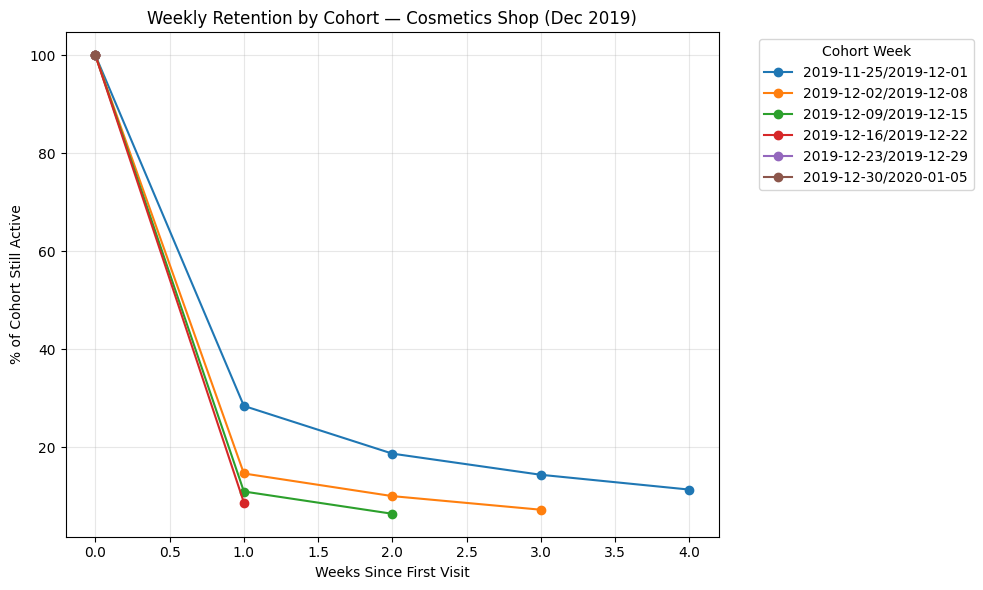

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for cohort in retention_pct_clean.index:
    plt.plot(retention_pct_clean.columns, retention_pct_clean.loc[cohort], marker='o', label=str(cohort))

plt.xlabel('Weeks Since First Visit')
plt.ylabel('% of Cohort Still Active')
plt.title('Weekly Retention by Cohort — Cosmetics Shop (Dec 2019)')
plt.legend(title='Cohort Week', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('retention_curve.png', dpi=150)
plt.show()

Note: Final observed period for each cohort excluded due to right-censoring
(dataset ends Dec 31, 2019 — the last visible period for late cohorts is
only partially complete and therefore not comparable to fully-observed periods).

In [21]:
os.listdir()

['.config',
 '2019-Dec.csv.zip',
 'retention_curve.png',
 '2019-Dec.csv',
 'sample_data']

In [22]:
from google.colab import files
files.download('retention_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import numpy as np
np.random.seed(42)

df['group'] = np.random.choice(['A', 'B'], size=len(df))

In [24]:
purchases = df[df['event_type'] == 'purchase']

group_a_users = purchases[purchases['group'] == 'A']['user_id'].nunique()
group_b_users = purchases[purchases['group'] == 'B']['user_id'].nunique()

total_a = df[df['group'] == 'A']['user_id'].nunique()
total_b = df[df['group'] == 'B']['user_id'].nunique()

conv_a = group_a_users / total_a * 100
conv_b = group_b_users / total_b * 100

print(f"Group A conversion: {conv_a:.2f}%")
print(f"Group B conversion: {conv_b:.2f}%")

Group A conversion: 8.73%
Group B conversion: 8.77%


In [25]:
from statsmodels.stats.proportion import proportions_ztest

count = [group_a_users, group_b_users]
nobs = [total_a, total_b]

stat, pval = proportions_ztest(count, nobs)

print(f"Z-statistic: {stat:.3f}")
print(f"P-value: {pval:.3f}")

Z-statistic: -0.497
P-value: 0.619


In [26]:
funnel_df.to_csv('funnel_summary.csv', index=False)
retention_pct_clean.to_csv('retention_cohorts.csv')

from google.colab import files
files.download('funnel_summary.csv')
files.download('retention_cohorts.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
retention_pct_clean.columns = [f'Week {c}' for c in retention_pct_clean.columns]
retention_pct_clean.to_csv('retention_cohorts.csv')

from google.colab import files
files.download('retention_cohorts.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
ab_summary = pd.DataFrame({
    'metric': ['Group A Conversion %', 'Group B Conversion %'],
    'value': [conv_a, conv_b]
})
ab_summary.to_csv('ab_test_summary.csv', index=False)

from google.colab import files
files.download('ab_test_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>